In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

from hepattn.experiments.clic.performance.performance import Performance, PerformanceConfig
from hepattn.experiments.clic.performance.plot_helper import PlotHelper

In [3]:
!pip install atlas-ftag-tools

Defaulting to user installation because normal site-packages is not writeable


In [4]:
cd /storage/agrp/barakma/hepattn/

/storage/agrp/barakma/hepattn


In [14]:
config_dict = {
    "truth_path": "/storage/agrp/dmitrykl/hgpf/hepformer/data/nilo/test_clic_common_raw.root",
    "networks": [
        {
            "name": "oddflow",
            "path": "/storage/agrp/barakma/hepattn/src/hepattn/experiments/odd/logs/odd_pflow_v1_clic_arch_20260112-T143417/ckpts/epoch=199-val_loss=4.48795__test.root",
            "network_type": "mpflow_proxy",
            "ind_threshold": 0.65,
        },
        #{
        #    "name": "hgpflow",
        #    "path": "/storage/agrp/nilotpal/HGPFlow_v2/experiments/hgpflow_v2/clicxminixbig1x2xs2xxxds7kirm1yo/inference/ee_qq_new/pred_test_p8_ee_qq_ecm380_20k_seg_bw0.3_nocut_merged.root",
        #    "network_type": "hgpflow_proxy",
        #    "ind_threshold": 0.65,
        #},
        #{
        #    "name": "mlpf",
        #    "path": "/srv01/agrp/dmitrykl/projects/mlpf/particleflow/experiments/pyg-clic-my_20250726_155449_087474/test/preds_common_checkpoint-21-2.657597/batch_size",
        #    "network_type": "mlpf",
        #},
    ],
}

In [15]:
config = PerformanceConfig.from_dict(config_dict)

In [16]:
perf_obj = Performance(config)

E, pT will be scaled by 1


Reading truth tree...:   0%|                                                                                                | 0/11 [00:00<?, ?it/s]

Reading truth tree...: 100%|███████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00,  5.98it/s]


Number of events with at least one track or topocluster: 19998 out of 20000
[[ 1399]
 [11288]]
Number of events after filtering: 19998


Computing mpflow mass...: 100%|███████████████████████████████████████████████████████████████████████████████| 694/694 [00:00<00:00, 31048.70it/s]


In [17]:
perf_obj.reorder_and_find_intersection()

common event count: 694


Filtering truth...:   0%|                                                                                                    | 0/8 [00:00<?, ?it/s]

Filtering and reordering pandora...: 100%|██████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 497.65it/s]


In [19]:
perf_obj.compute_jets(n_procs=20)

Jet clustering algorithm:  genkt
Jet clustering radius:  0.7
truth


Computing jets...: 100%|████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 84.77Chunk/s]


Computing jets for oddflow...


Computing jets...: 100%|████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 34.81Chunk/s]


Computing jets for pandora...


Computing jets...: 100%|████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 76.47Chunk/s]


In [20]:
perf_obj.hung_match_jets()
perf_obj.compute_event_features()
perf_obj.compute_jet_res_features(dr_cut=0.1, leading_n_jets=2, pt_min=10)

Matching jets...:   0%|                                                                                                    | 0/694 [00:00<?, ?it/s]

Matching jets...: 100%|███████████████████████████████████████████████████████████████████████████████████████| 694/694 [00:00<00:00, 59793.09it/s]


In [21]:
from collections import defaultdict


def default_style_dict():
    return {
        "histtype": "step",
        "linewidth": 1,
    }


style_dict = defaultdict(default_style_dict)
style_dict["pandora"] = {
    "color": "gray",
    "alpha": 0.5,
    "histtype": "stepfilled",
}

In [22]:
plot_helper = PlotHelper(perf_obj, style_dict=style_dict)

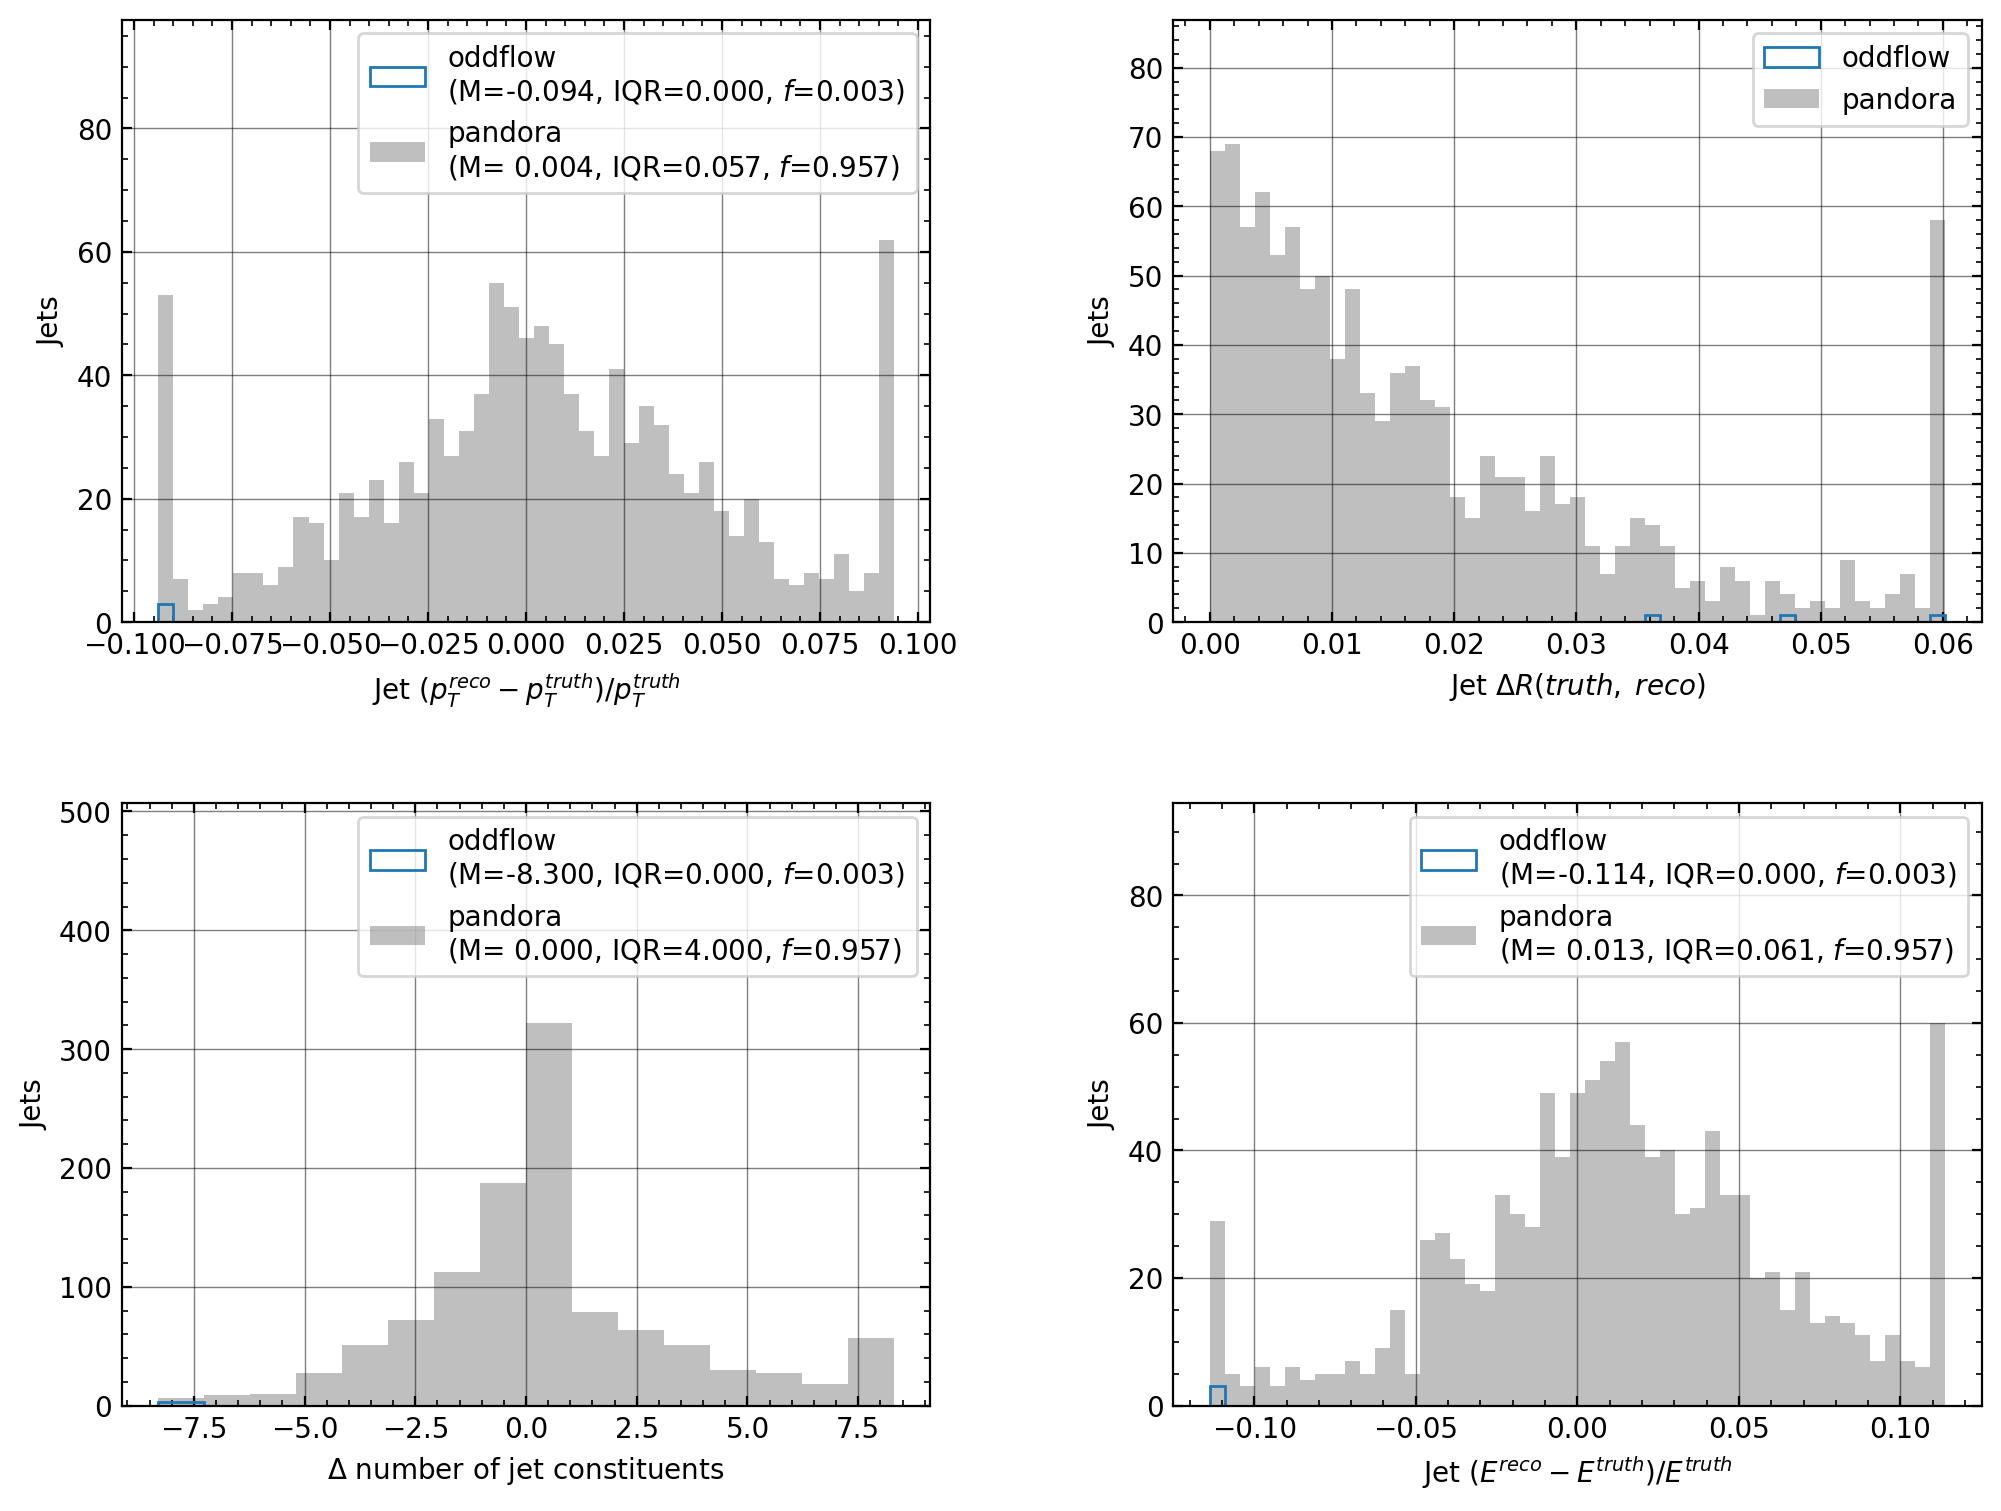

In [23]:
fig = plot_helper.plot_jet_residuals()

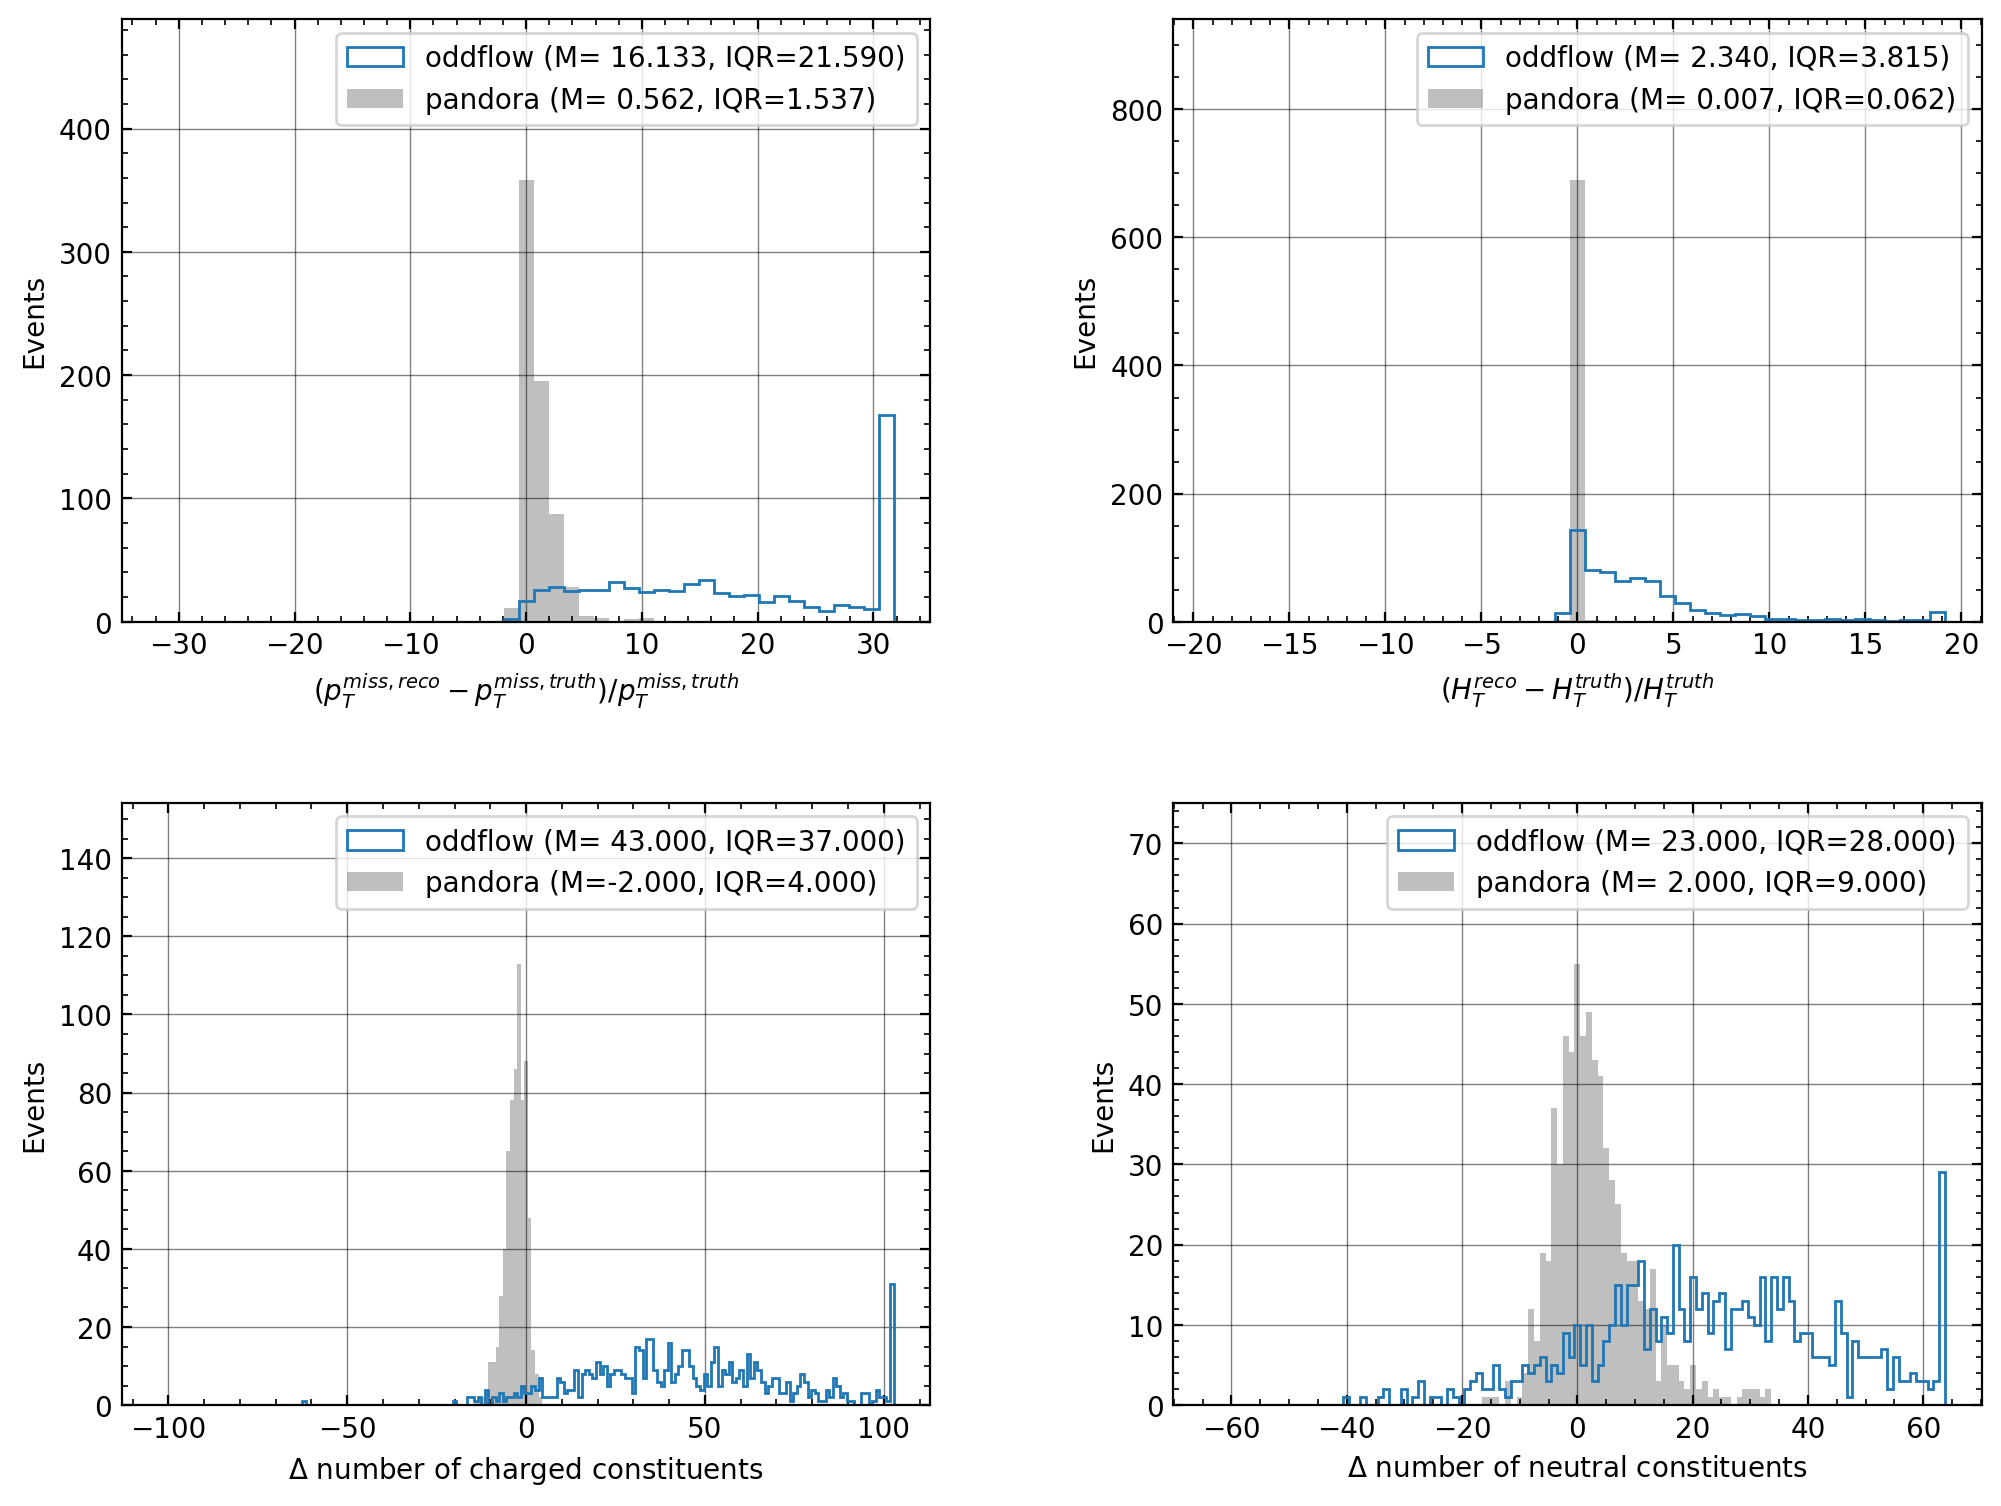

In [24]:
fig = plot_helper.plot_evt_res()

In [25]:
pt_bins = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200])

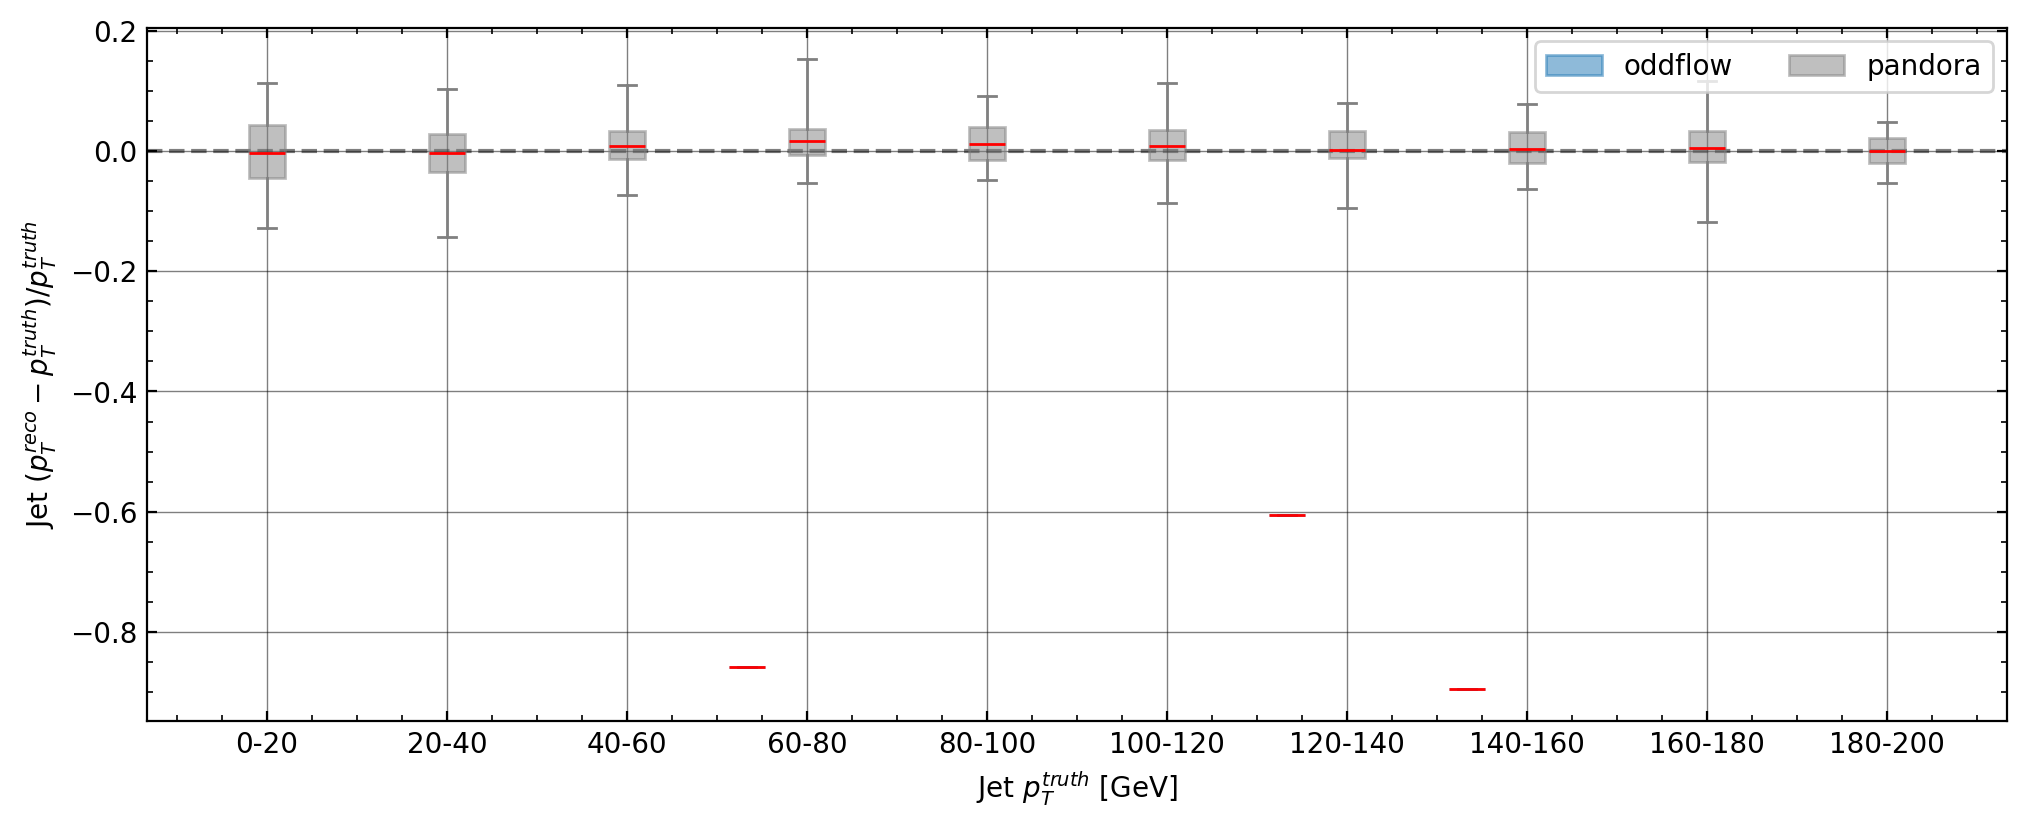

In [26]:
fig = plot_helper.plot_jet_res_boxplot(bins=pt_bins)

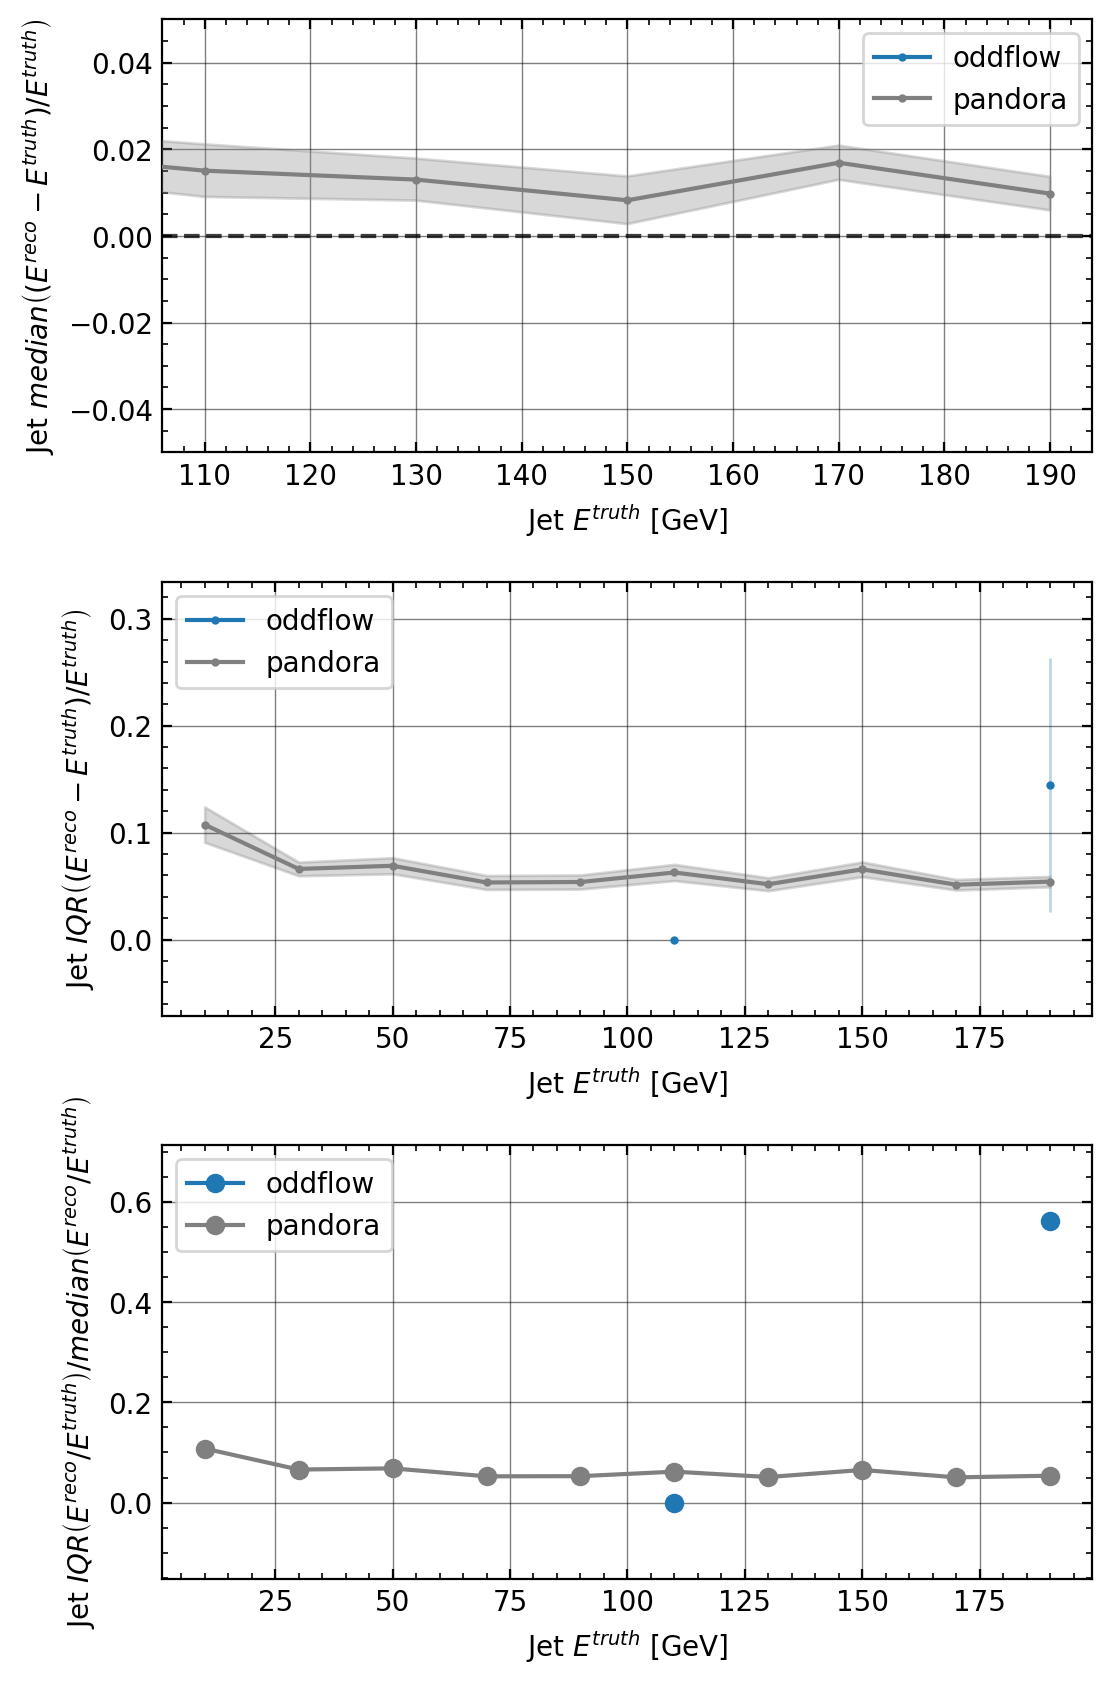

In [27]:
fig = plot_helper.plot_jet_response(pt_bins=pt_bins, use_energy=True)

In [28]:
perf_obj.hung_match_particles(flatten=True, return_unmatched=True)

Matching particles...: 100%|███████████████████████████████████████████████████████████████████████████████████| 694/694 [00:00<00:00, 4005.32it/s]


/storage/agrp/barakma/hepattn/src/hepattn/experiments/clic/performance/plot_helper_particle.py:98: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, ax.get_ylim()[1] * (1 + len(residual_dict) * 0.23))


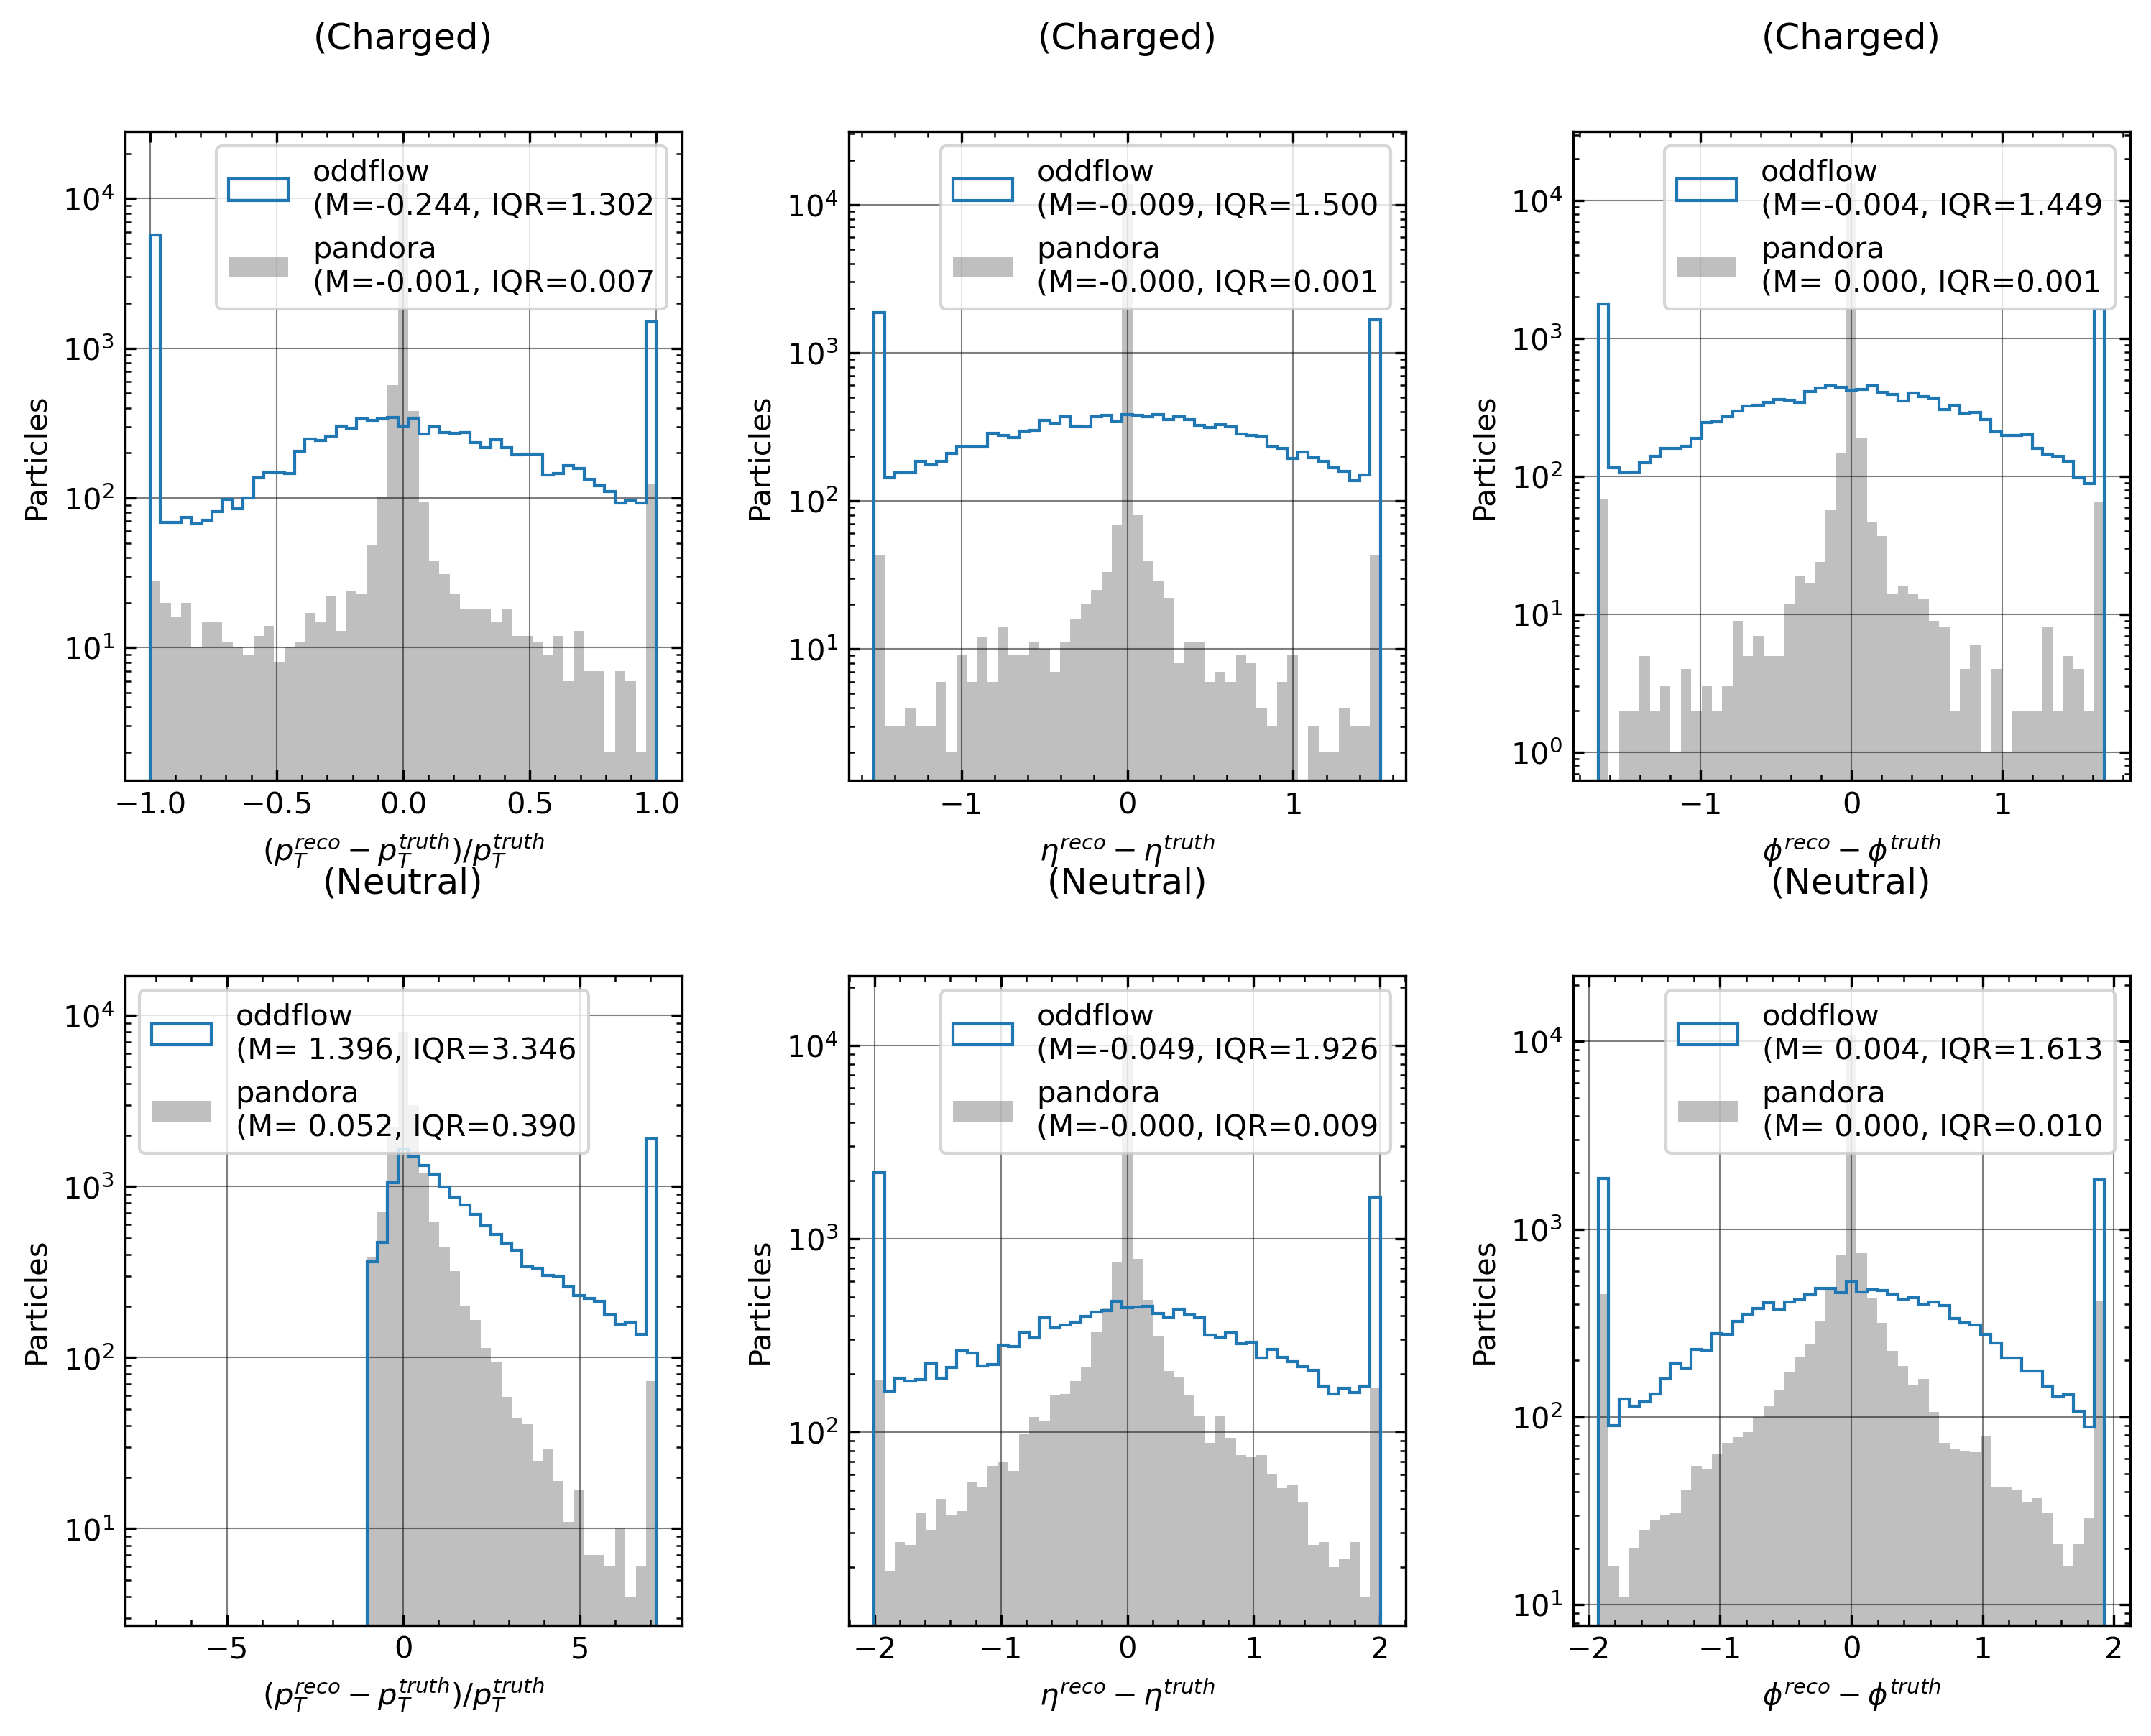

In [29]:
qs = {"Charged": {"pt": 90, "eta": 80, "phi": 80}, "Neutral": {"pt": 90, "eta": 80, "phi": 80}}
fig = plot_helper.plot_residuals(pt_relative=True, log_y=True, qs=qs)

In [31]:
qs = {"Neutral hadron": {"pt": 98, "eta": 75, "phi": 75}, "Photon": {"pt": 99, "eta": 90, "phi": 90}}
fig = plot_helper.plot_residuals_neutrals(pt_relative=True, log_y=True, qs=qs)

In [ ]:
eff_fr_colors = {
    "mpflow": {
        "neut had": "mediumseagreen",
        "photon": "tomato",
    },
    "hgpflow": {
        "neut had": "steelblue",
        "photon": "darkorange",
    },
    "pandora": {
        "neut had": "dodgerblue",
        "photon": "goldenrod",
    },
    "mlpf": {
        "neut had": "crimson",
        "photon": "darkviolet",
    },
}

In [ ]:
plot_helper.plot_eff_fr_purity(eff_fr_colors)